In [1]:
import os 
import numpy as np
import xarray as xr
import re

In [2]:
root = "/r/scratch/groups/nm/downscaling/cordex-ALPS-allyear"
pattern = re.compile(r'tas_day_EUR-11_([\w-]+)_([\w-]+)_r1i1p1_rcp85_ALPS_cordexgrid_train-period.nc')

# List all filenames in the directory
file_names = os.listdir(root + "/train")

# Extract GCM-RCM combinations from file names
rcm_gcm_combinations = []
for file_name in file_names:
    match = pattern.match(file_name)
    if match:
        rcm_gcm_combinations.append((match.group(1), match.group(2)))

In [3]:
rcm_gcm_combinations

[('CCLM4-8-17', 'CNRM-CM5'),
 ('REMO2015', 'MIROC5'),
 ('RegCM4-6', 'CNRM-CM5'),
 ('CCLM4-8-17', 'MPI-ESM-LR'),
 ('ALADIN63', 'MPI-ESM-LR'),
 ('ALADIN63', 'CNRM-CM5'),
 ('CCLM4-8-17', 'MIROC5'),
 ('RegCM4-6', 'MPI-ESM-LR')]

In [4]:
gcm_list = list(set([x[1] for x in rcm_gcm_combinations]))

In [5]:
gcm_list

['MPI-ESM-LR', 'MIROC5', 'CNRM-CM5']

In [6]:
import matplotlib.pyplot as plt
import torch

In [7]:
def correct_units(data, data_type = "tas"):
    if data_type == "pr" and data.mean() < 0.1:
        return data * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
    elif data_type == "tas" and data.mean() > 100:
        return data - 273.15 # if no normalisation, convert from K to C
    else:
        return data

## Norm stats pixelwise and over entire field

In [34]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for data_type in ["tas", "sfcWind", "rsds"]:
        print(data_type)               
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
            
        if data_type in ["pr", "sfcWind"]:
            hr_data = torch.sqrt(hr_data)
        
        # COMPUTE NORM STATS        
        hr_std_all = torch.std(hr_data)
        hr_mean_all = torch.mean(hr_data)
        
        if data_type in ["pr", "sfcWind"]:
            name_str = "_sqrt"
        else:
            name_str = ""
            
        torch.save({"mean": hr_mean_all, "std": hr_std_all},
            os.path.join(root, "norm_stats", "hr_norm_stats_full-data_" + data_type + "_train_" + rcm + "_" + gcm + name_str + ".pt"))
        
        hr_std_pw = torch.std(hr_data, dim=0)
        hr_mean_pw = torch.mean(hr_data, dim=0)
    
        torch.save({"mean": hr_mean_pw, "std": hr_std_pw},
            os.path.join(root, "norm_stats", "hr_norm_stats_pixelwise_" + data_type + "_train_" + rcm + "_" + gcm + name_str + ".pt"))
        
        hr_norm = (hr_data - hr_mean_pw) / hr_std_pw
        plt.imshow(hr_norm[0, :, :].detach().numpy())

CCLM4-8-17 CNRM-CM5
tas
sfcWind
rsds
REMO2015 MIROC5
tas
sfcWind
rsds
RegCM4-6 CNRM-CM5
tas
sfcWind
rsds
CCLM4-8-17 MPI-ESM-LR
tas
sfcWind
rsds
ALADIN63 MPI-ESM-LR
tas
sfcWind
rsds
ALADIN63 CNRM-CM5
tas
sfcWind
rsds
CCLM4-8-17 MIROC5
tas
sfcWind
rsds
RegCM4-6 MPI-ESM-LR
tas
sfcWind
rsds


One norm stats for all data -> easier in training

pr
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


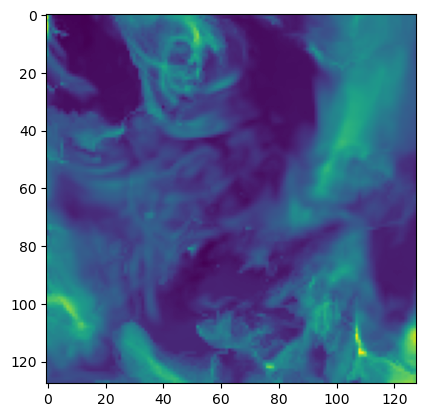

In [8]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0)                        
    if data_type in ["pr", "sfcWind"]:
        hr_data = torch.sqrt(hr_data)

    # COMPUTE NORM STATS        
    hr_std_all = torch.std(hr_data)
    hr_mean_all = torch.mean(hr_data)

    if data_type in ["pr", "sfcWind"]:
        name_str = "_sqrt"
    else:
        name_str = ""
        
    torch.save({"mean": hr_mean_all, "std": hr_std_all},
        os.path.join(root, "norm_stats", "hr_norm_stats_full-data_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

    hr_std_pw = torch.std(hr_data, dim=0)
    hr_mean_pw = torch.mean(hr_data, dim=0)

    torch.save({"mean": hr_mean_pw, "std": hr_std_pw},
        os.path.join(root, "norm_stats", "hr_norm_stats_pixelwise_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

    hr_norm = (hr_data - hr_mean_pw) / hr_std_pw
    plt.imshow(hr_norm[0, :, :].detach().numpy())

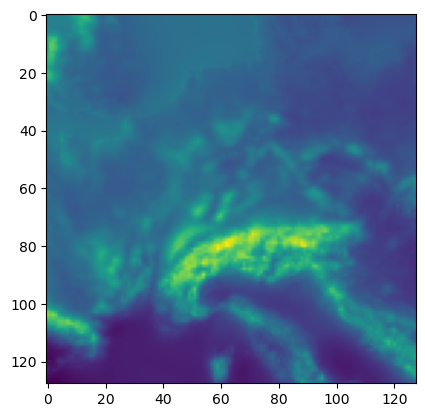

In [9]:
plt.imshow(hr_mean_pw.detach().numpy())

Same without sqrt

pr
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR
sfcWind
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


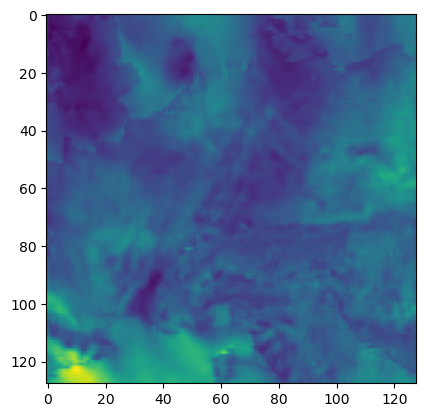

In [9]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr", "sfcWind"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 

    # COMPUTE NORM STATS        
    hr_std_all = torch.std(hr_data)
    hr_mean_all = torch.mean(hr_data)
    name_str = ""
        
    torch.save({"mean": hr_mean_all, "std": hr_std_all},
        os.path.join(root, "norm_stats", "hr_norm_stats_full-data_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

    hr_std_pw = torch.std(hr_data, dim=0)
    hr_mean_pw = torch.mean(hr_data, dim=0)

    torch.save({"mean": hr_mean_pw, "std": hr_std_pw},
        os.path.join(root, "norm_stats", "hr_norm_stats_pixelwise_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

    hr_norm = (hr_data - hr_mean_pw) / hr_std_pw
    plt.imshow(hr_norm[0, :, :].detach().numpy())

Compute LR

Per GCM

In [12]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for gcm in gcm_list:
    print(gcm)
    for data_type in ["psl", "tas", "pr", "sfcWind", "rsds"]:
        lr_path = os.path.join(root, folder, data_type + "_day_" + gcm + "_" + variant + "_rcp85_EUROPE_g025" +  file_suffix + ".nc")
        lr_ds = xr.open_dataset(lr_path)
        lr_data = torch.flip(torch.from_numpy(lr_ds[data_type].data), [1])
        lr_data = correct_units(lr_data, data_type)
        
        if data_type in ["pr", "sfcWind"]:
            lr_data = torch.sqrt(lr_data)
        
        if data_type in ["pr", "sfcWind"]:
            name_str = "_sqrt"
        else:
            name_str = ""
        
        # COMPUTE NORM STATS
        lr_std_all = torch.std(lr_data)
        lr_mean_all = torch.mean(lr_data)
        
        torch.save({"mean": lr_mean_all, "std": lr_std_all},
            os.path.join(root, "norm_stats", "lr_norm_stats_full-data_" + data_type + "_train_" + gcm + name_str + ".pt"))
        
        lr_std_pw = torch.std(lr_data, dim=0)
        lr_mean_pw = torch.mean(lr_data, dim=0)
    
        torch.save({"mean": lr_mean_pw, "std": lr_std_pw},
            os.path.join(root, "norm_stats", "lr_norm_stats_pixelwise_" + data_type + "_train_" + gcm + name_str + ".pt"))

MPI-ESM-LR
CNRM-CM5
MIROC5


All

In [8]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["psl", "tas", "pr", "sfcWind", "rsds"]:
    print(data_type)  
    lr_data_list = []  
    for gcm in gcm_list:
        print(gcm)
        lr_path = os.path.join(root, folder, data_type + "_day_" + gcm + "_" + variant + "_rcp85_EUROPE_g025" +  file_suffix + ".nc")
        lr_ds = xr.open_dataset(lr_path)
        lr_data = torch.flip(torch.from_numpy(lr_ds[data_type].data), [1])
        lr_data = correct_units(lr_data, data_type)
        
        if data_type in ["pr", "sfcWind"]:
            lr_data = torch.sqrt(lr_data)
            
        lr_data_list.append(lr_data)

    if data_type in ["pr", "sfcWind"]:
            name_str = "_sqrt"
    else:
            name_str = ""    
        
    lr_data = torch.cat(lr_data_list, dim=0)
    
    # COMPUTE NORM STATS
    lr_std_all = torch.std(lr_data)
    lr_mean_all = torch.mean(lr_data)
    
    torch.save({"mean": lr_mean_all, "std": lr_std_all},
        os.path.join(root, "norm_stats", "lr_norm_stats_full-data_" + data_type + "_train_ALL" + name_str + ".pt"))
    
    lr_std_pw = torch.std(lr_data, dim=0)
    lr_mean_pw = torch.mean(lr_data, dim=0)

    torch.save({"mean": lr_mean_pw, "std": lr_std_pw},
        os.path.join(root, "norm_stats", "lr_norm_stats_pixelwise_" + data_type + "_train_ALL" + name_str + ".pt"))

psl
MPI-ESM-LR
MIROC5
CNRM-CM5
tas
MPI-ESM-LR
MIROC5
CNRM-CM5
pr
MPI-ESM-LR
MIROC5
CNRM-CM5
sfcWind
MPI-ESM-LR
MIROC5
CNRM-CM5
rsds
MPI-ESM-LR
MIROC5
CNRM-CM5


Without sqrt

In [9]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr", "sfcWind"]:
    print(data_type)  
    lr_data_list = []  
    for gcm in gcm_list:
        print(gcm)
        lr_path = os.path.join(root, folder, data_type + "_day_" + gcm + "_" + variant + "_rcp85_EUROPE_g025" +  file_suffix + ".nc")
        lr_ds = xr.open_dataset(lr_path)
        lr_data = torch.flip(torch.from_numpy(lr_ds[data_type].data), [1])
        lr_data = correct_units(lr_data, data_type)
        lr_data_list.append(lr_data)
        
    lr_data = torch.cat(lr_data_list, dim=0)
    name_str = ""
    
    # COMPUTE NORM STATS
    lr_std_all = torch.std(lr_data)
    lr_mean_all = torch.mean(lr_data)
    
    torch.save({"mean": lr_mean_all, "std": lr_std_all},
        os.path.join(root, "norm_stats", "lr_norm_stats_full-data_" + data_type + "_train_ALL" + name_str + ".pt"))
    
    lr_std_pw = torch.std(lr_data, dim=0)
    lr_mean_pw = torch.mean(lr_data, dim=0)

    torch.save({"mean": lr_mean_pw, "std": lr_std_pw},
        os.path.join(root, "norm_stats", "lr_norm_stats_pixelwise_" + data_type + "_train_ALL" + name_str + ".pt"))

pr
MPI-ESM-LR
MIROC5
CNRM-CM5
sfcWind
MPI-ESM-LR
MIROC5
CNRM-CM5


hus, va, ua

In [12]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["zg"]:
    print(data_type)  
    lr_data_list = []  
    for gcm in gcm_list[:2]:
        print(gcm)
        lr_path = os.path.join(root, folder, data_type + "_day_" + gcm + "_" + variant + "_rcp85_EUROPE_g025" +  file_suffix + ".nc")
        lr_ds = xr.open_dataset(lr_path)
        print(lr_ds[data_type].mean())
        lr_data = torch.flip(torch.from_numpy(lr_ds[data_type].data), [2])
        print(lr_data.shape)
        lr_data = torch.mean(lr_data, dim=1)
        print(lr_data.shape)
        lr_data = correct_units(lr_data, data_type)
        lr_data_list.append(lr_data)
        
    
    name_str = ""
    lr_data = torch.cat(lr_data_list, dim=0)
    
    # COMPUTE NORM STATS
    lr_std_all = torch.std(lr_data)
    lr_mean_all = torch.mean(lr_data)
    
    torch.save({"mean": lr_mean_all, "std": lr_std_all},
        os.path.join(root, "norm_stats", "lr_norm_stats_full-data_" + data_type + "_train_ALL" + name_str + ".pt"))
    
    lr_std_pw = torch.std(lr_data, dim=0)
    lr_mean_pw = torch.mean(lr_data, dim=0)

    torch.save({"mean": lr_mean_pw, "std": lr_std_pw},
        os.path.join(root, "norm_stats", "lr_norm_stats_pixelwise_" + data_type + "_train_ALL" + name_str + ".pt"))

zg
CNRM-CM5
<xarray.DataArray 'zg' ()>
array(3521.233, dtype=float32)
torch.Size([39813, 2, 20, 36])
torch.Size([39813, 20, 36])
MPI-ESM-LR
<xarray.DataArray 'zg' ()>
array(3527.8533, dtype=float32)
torch.Size([39813, 2, 20, 36])
torch.Size([39813, 20, 36])


## ECDF

### all data

In [12]:
from scipy.stats import ecdf

In [49]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 

    # COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant')
            if i == 0 and j == 0:
                probs = pw_ecdf.cdf.probabilities        
            # assert np.all(pw_ecdf.cdf.probabilities == probs)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
        os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

pr
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


In [50]:
len(hr_data)

318448

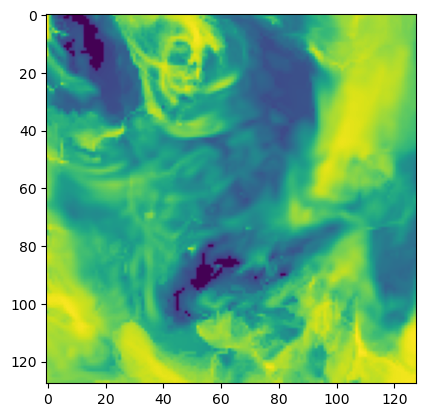

In [32]:
hr_norm = np.zeros_like(hr_data)
for i in range(hr_data.shape[1]):
    for j in range(hr_data.shape[2]):
        quantiles = ecdf_matrix[:, i, j]
        hr_norm[:, i, j] =  np.interp(hr_data[:, i, j].detach().numpy(), quantiles, 
                                      np.pad(probs, (hr_data.shape[0] - len(probs), 0), mode='constant'))
plt.imshow(hr_norm[0, :, :])

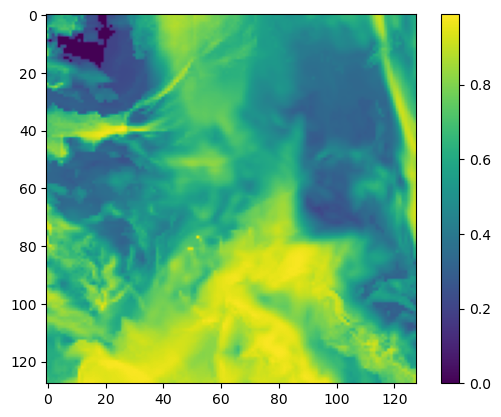

In [34]:
plt.imshow(hr_norm[10, :, :])
plt.colorbar()

Plot ecdf quantiles

In [13]:
data_type = "pr"
name_str = ""
ecdf_matrix = torch.load(
        os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "ALL" + name_str + ".pt"))

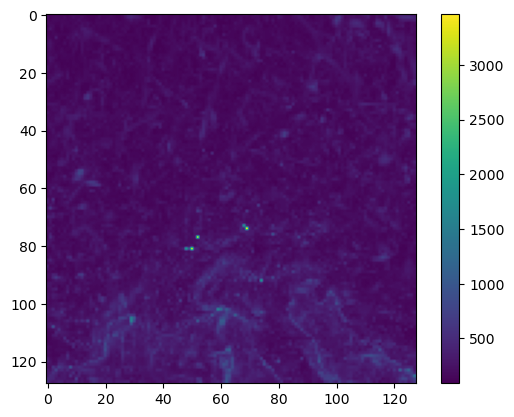

In [24]:
plt.imshow(ecdf_matrix[-1, :, :])
plt.colorbar()

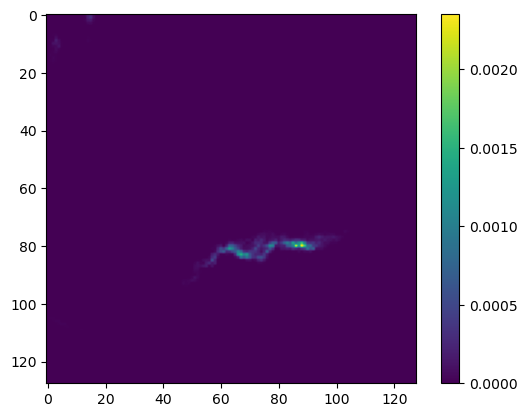

In [26]:
plt.imshow(ecdf_matrix[39500, :, :])
plt.colorbar()

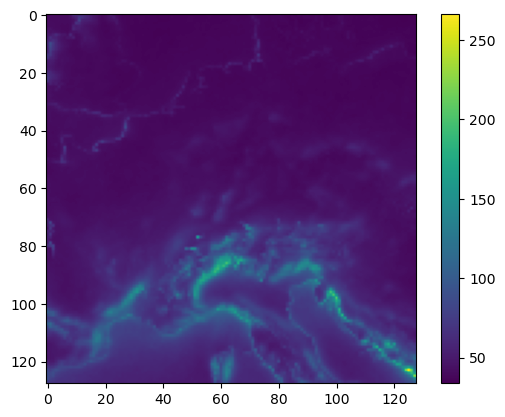

In [35]:
plt.imshow(ecdf_matrix[-318, :, :])
plt.colorbar()

In [34]:
0.001 * len(ecdf_matrix)

318.448

Check maxima

In [45]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations[3:4]:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)

pr
CCLM4-8-17 MPI-ESM-LR


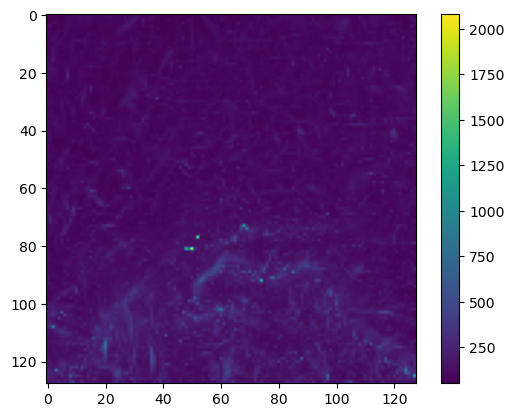

In [46]:
plt.imshow(torch.max(hr_data, dim=0)[0].detach().numpy())
plt.colorbar()

### Repeat with random sub-sample

In [8]:
from scipy.stats import ecdf

precip

In [71]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 
    
    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

    # COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            # ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant') old version
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
       os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))

pr
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


tas

In [30]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["tas"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 

    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)
    
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            # PRECIP OLD ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant')
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
        os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))
    

tas
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


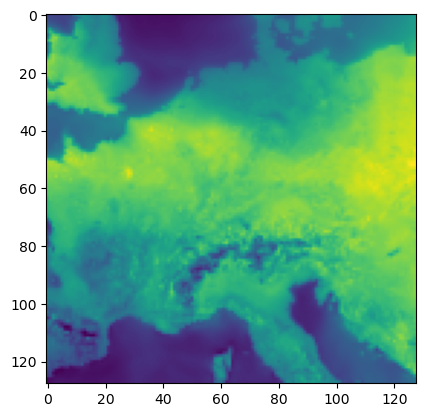

In [31]:
hr_norm = np.zeros_like(hr_data)
for i in range(hr_data.shape[1]):
    for j in range(hr_data.shape[2]):
        quantiles = ecdf_matrix[:, i, j]
        hr_norm[:, i, j] =  np.interp(hr_data[:, i, j].detach().numpy(), quantiles, probs)
plt.imshow(hr_norm[0, :, :])

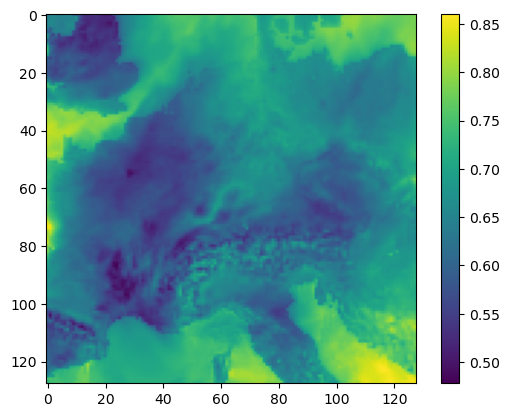

In [33]:
plt.imshow(hr_norm[10, :, :])
plt.colorbar()

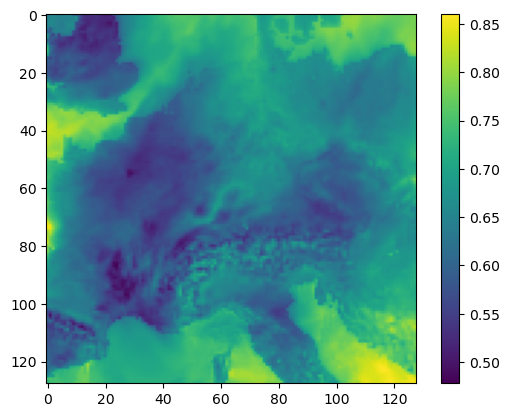

In [34]:
plt.imshow(hr_norm[10, :, :])
plt.colorbar()

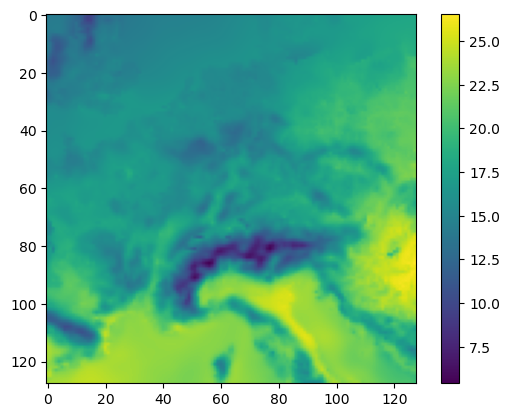

In [36]:
plt.imshow(hr_data[100, :, :])
plt.colorbar()

rsds

In [9]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["rsds"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 

    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)
    
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            # PRECIP OLD ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant')
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
        os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))
    

rsds
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


sfcWind

In [10]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["sfcWind"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 
    
    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

    # COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            # ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant') old version
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
       os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))

sfcWind
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


Test with subsample

In [10]:
from scipy.stats import ecdf

In [38]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations[:2]:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        hr_data_list.append(hr_data)

    hr_data = torch.cat(hr_data_list, dim=0) 

    subsample_size = int(30e2)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]

pr
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5


In [39]:
len_full_data = subsample_size
probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

In [61]:
for data_type in ["pr"]:
# COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
            ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant')
            # ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)

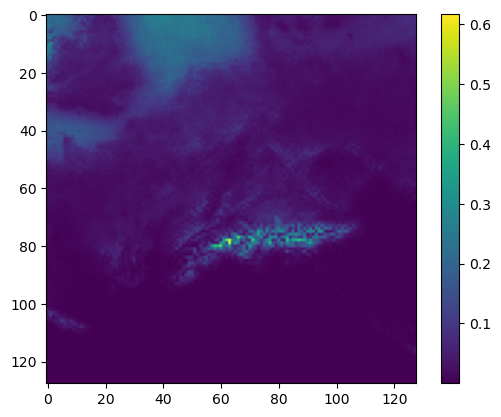

In [62]:
plt.imshow(ecdf_matrix[1000, :, :])
plt.colorbar()

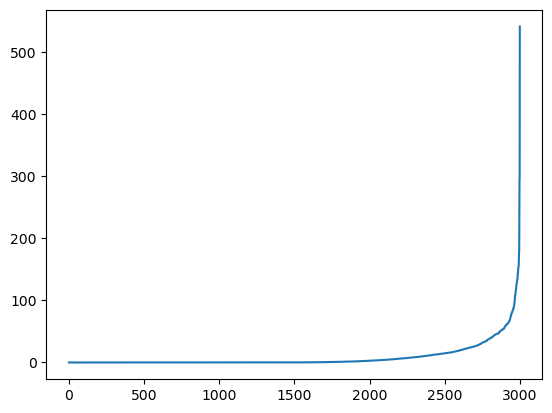

In [63]:
plt.plot(ecdf_matrix[:, 100, 100])

In [64]:
hr_norm = np.zeros_like(hr_data)
for i in range(hr_data.shape[1]):
    for j in range(hr_data.shape[2]):
        quantiles = ecdf_matrix[:, i, j]
        hr_norm[:, i, j] =  np.interp(hr_data[:, i, j].detach().numpy(), quantiles, probs)

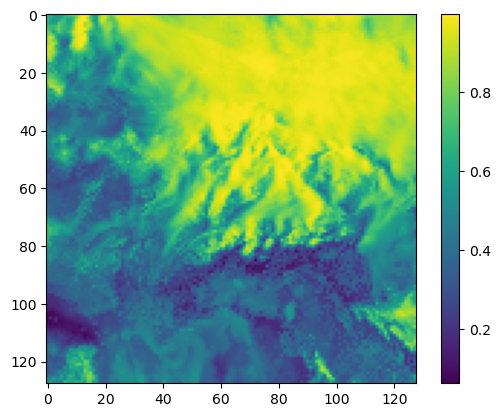

In [65]:
plt.imshow(hr_norm[0, :, :])
plt.colorbar()

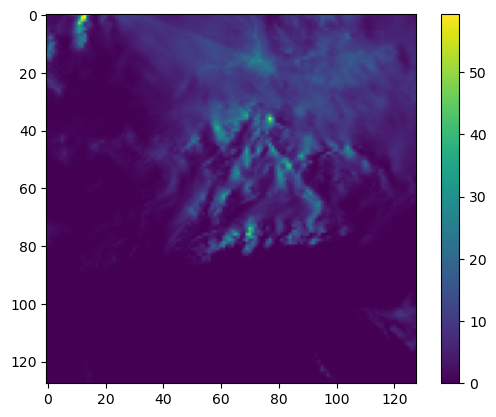

In [66]:
plt.imshow(hr_data[0, :, :])
plt.colorbar()

(array([558., 271., 271., 272., 271., 271., 272., 271., 271., 272.]),
 array([0.09566667, 0.18610001, 0.27653334, 0.36696666, 0.45739999,
        0.54783332, 0.63826668, 0.72869998, 0.81913334, 0.90956664,
        1.        ]),
 <BarContainer object of 10 artists>)

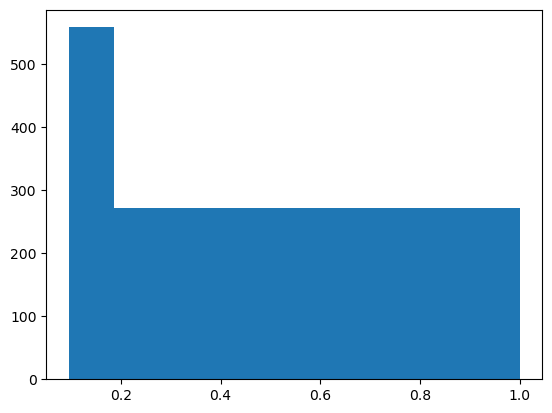

In [69]:
plt.hist(hr_norm[:, 0, 0])

(array([524., 275., 276., 274., 275., 275., 275., 275., 275., 276.]),
 array([0.08333334, 0.175     , 0.26666668, 0.35833335, 0.44999999,
        0.54166669, 0.63333333, 0.72500002, 0.81666666, 0.90833336,
        1.        ]),
 <BarContainer object of 10 artists>)

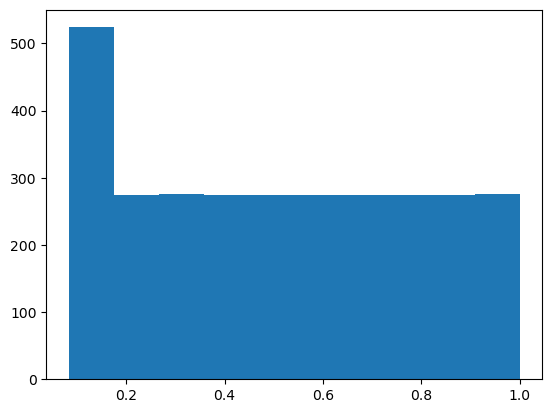

In [70]:
plt.hist(hr_norm[:, 10, 10])

### Compute normalised fields to save on disk. 
(Repeat with random subsample.)

Repeat with 1/(n+1)
**Added flipping of ecdf matrix back to xr dataset orientation**

In [72]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)
            file_path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
            # if os.path.exists(file_path):
            #    continue                 
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    hr_ds_norm[data_type][:, i, j] = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    # trying to improve efficiency: 
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
            try:
            # if True:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)
            

CCLM4-8-17 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
REMO2015 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr


In [12]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["sfcWind"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)
            file_path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
            #if os.path.exists(file_path):
            #    continue                 
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    hr_ds_norm[data_type][:, i, j] = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    # trying to improve efficiency: 
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
            try:
            # if True:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)

CCLM4-8-17 CNRM-CM5
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
REMO2015 MIROC5
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
RegCM4-6 CNRM-CM5
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
CCLM4-8-17 MPI-ESM-LR
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
ALADIN63 MPI-ESM-LR
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
ALADIN63 CNRM-CM5
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
CCLM4-8-17 MIROC5
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind
RegCM4-6 MPI-ESM-LR
train
sfcWind
test_interpolation
sfcWind
test_extrapolation
sfcWind


### Randomise the ties for precipitation

In [8]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)                
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    data_norm = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    
                    # trying to improve efficiency - not helping much:
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
                    
                    # ADD RANDOMISATION FOR [0, P(X = 0)]                    
                    where_zeros = np.where(data_norm == np.min(data_norm))[0]
                    data_norm[where_zeros] = data_norm[where_zeros] - np.random.uniform(size = len(where_zeros)) * np.min(data_norm)
                    hr_ds_norm[data_type][:, i, j] = data_norm
            try:
            # if True:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-random.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-random.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)

CCLM4-8-17 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
REMO2015 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr


### Randomise the ties for precipitation but constant for each image

In [8]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)                
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            # one random realisation per time point
            unif_sample = np.random.uniform(size=hr_ds_cp[data_type].shape[0])
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    data_norm = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    
                    # trying to improve efficiency - not helping much:
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
                    
                    # ADD RANDOMISATION FOR [0, P(X = 0)]                    
                    where_zeros = np.where(data_norm == np.min(data_norm))[0]
                    data_norm[where_zeros] = data_norm[where_zeros] - unif_sample[where_zeros] * np.min(data_norm)
                    hr_ds_norm[data_type][:, i, j] = data_norm
            try:
            # if True:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-random-correlated.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-random-correlated.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)

CCLM4-8-17 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
REMO2015 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr
ALADIN63 CNRM-CM5
train
pr
test_interpolation
pr
test_extrapolation
pr
CCLM4-8-17 MIROC5
train
pr
test_interpolation
pr
test_extrapolation
pr
RegCM4-6 MPI-ESM-LR
train
pr
test_interpolation
pr
test_extrapolation
pr


In [12]:
for rcm, gcm in rcm_gcm_combinations[1:2]:
    print(rcm, gcm)
    for mode in ["train"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)                
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)

REMO2015 MIROC5
train
pr


In [13]:
hr_ds

<xarray.Dataset>
Dimensions:    (time: 39785, bnds: 2, y: 128, x: 128, nv4: 4)
Coordinates:
  * time       (time) object 1971-01-01 12:00:00 ... 2089-12-31 12:00:00
    lon        (y, x) float64 ...
    lat        (y, x) float64 ...
Dimensions without coordinates: bnds, y, x, nv4
Data variables:
    time_bnds  (time, bnds) object ...
    lon_bnds   (y, x, nv4) float64 ...
    lat_bnds   (y, x, nv4) float64 ...
    pr         (time, y, x) float32 ...
Attributes: (12/33)
    CDI:                            Climate Data Interface version 1.9.6 (htt...
    Conventions:                    CF-1.4
    history:                        Fri Feb 09 16:43:31 2024: cdo del29feb ar...
    source:                         GERICS-REMO2015
    institution:                    Helmholtz-Zentrum Geesthacht, Climate Ser...
    institute_id:                   GERICS
    ...                             ...
    modeling_realm:                 atmos
    realization:                    1
    cmor_version:                   2.9.1
    NCO:                            netCDF Operators version 4.7.6 (Homepage ...
    history_of_appended_files:      Fri Apr 30 16:26:16 2021: Appended file /...
    CDO:                            Climate Data Operators version 1.9.6 (htt...

In [10]:
hr_ds_norm["pr"]

<xarray.DataArray 'pr' (time: 3652, y: 128, x: 128)>
[59834368 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2090-01-01T12:00:00 ... 2099-12-31T12:00:00
    lon      (y, x) float64 ...
    lat      (y, x) float64 ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          mm/day
    cell_methods:   time: mean

### Randomise the ties plus filter extremes for precipitation

In [8]:
import numpy as np
from scipy.ndimage import generic_filter

def spatial_outlier_filter(arr, window_size=(3, 3), k=1.5, mode='clip'):
    """
    Filter outliers in a 2D array using a local window-based median + MAD threshold.

    Parameters:
    -----------
    arr : 2D numpy array
        Input field (e.g., temperature or precipitation).
    window_size : tuple of int
        Size of the neighborhood window (e.g., (3, 3), (5, 5)).
    k : float
        Multiplier for MAD to define the buffer: threshold = median + k * MAD.
    mode : str
        - 'clip': clip value to threshold if it exceeds it.
        - 'replace': replace outlier with neighborhood median.

    Returns:
    --------
    filtered : 2D numpy array
        Output array with outliers filtered.
    """
    assert arr.ndim == 2, "Input must be a 2D array."
    assert mode in ['clip', 'replace'], "Mode must be 'clip' or 'replace'."
    
    def filter_func(values):
        center = values[len(values) // 2]
        med = np.median(values)
        mad = np.median(np.abs(values - med))
        threshold = med + k * mad
        
        if center > threshold:
            return med if mode == 'replace' else threshold
        else:
            return center

    footprint = np.ones(window_size, dtype=bool)
    return generic_filter(arr, filter_func, footprint=footprint, mode='nearest')


In [9]:
import cupy as cp
from cupyx.scipy.ndimage import median_filter

def gpu_spatial_outlier_filter_2d(arr2d, window_size=3, k=1.5, mode='clip'):
    assert arr2d.ndim == 2
    pad = window_size // 2
    padded = cp.pad(arr2d, pad, mode='edge')
    windows = cp.lib.stride_tricks.sliding_window_view(padded, (window_size, window_size))
    H, W = arr2d.shape
    windows = windows[:H, :W]  # shape (H, W, win, win)

    flat = windows.reshape(H, W, -1)  # includes the center

    # Compute stats including center
    med = cp.median(flat, axis=-1)
    mad = cp.median(cp.abs(flat - med[..., None]), axis=-1)
    threshold = med + k * mad

    if mode == 'clip':
        return cp.minimum(arr2d, threshold)
    elif mode == 'replace':
        out = arr2d.copy()
        mask = arr2d > threshold
        out[mask] = med[mask]
        return out
    else:
        raise ValueError("mode must be 'clip' or 'replace'")



In [10]:
def gpu_filter_3d(data3d, window_size=3, k=1.5, mode='clip'):
    data_gpu = cp.asarray(data3d)
    filtered = cp.stack([
        gpu_spatial_outlier_filter_2d(data_gpu[t], window_size, k, mode)
        for t in range(data_gpu.shape[0])
    ])
    return cp.asnumpy(filtered)  # back to CPU if needed


In [11]:
variant = "r1i1p1"
name_str = ""
from joblib import Parallel, delayed

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)                
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()

            # SLOW version
            #hr_ds_norm_array = np.array(Parallel(n_jobs=10)(
            #    delayed(spatial_outlier_filter)(hr_ds_norm[data_type].values[t], window_size=(3, 3), k=5)
            #    for t in range(hr_ds_norm[data_type].values.shape[0])
            #))
            
            # fast version
            hr_ds_norm[data_type].values = gpu_filter_3d(hr_ds_norm[data_type].values, window_size=3, k=5, mode='clip')
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    data_norm = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    
                    # trying to improve efficiency - not helping much:
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
                    
                    # ADD RANDOMISATION FOR [0, P(X = 0)]                    
                    where_zeros = np.where(data_norm == np.min(data_norm))[0]
                    data_norm[where_zeros] = data_norm[where_zeros] - np.random.uniform(size = len(where_zeros)) * np.min(data_norm)
                    hr_ds_norm[data_type][:, i, j] = data_norm

            path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-random-filtered.nc")
            hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)

CCLM4-8-17 CNRM-CM5
train
pr


OutOfMemoryError: Out of memory allocating 5,218,369,536 bytes (allocated so far: 10,441,709,568 bytes).

Filter extremes for rsds

In [ ]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["rsds"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)
            file_path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
            #if os.path.exists(file_path):
            #    continue                 
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            hr_ds_norm_array = np.array(Parallel(n_jobs=10)(
                delayed(spatial_outlier_filter)(hr_ds_norm[data_type].values[t], window_size=(3, 3), k=5)
                for t in range(hr_ds_norm[data_type].values.shape[0])
            ))
            hr_ds_norm[data_type].values = hr_ds_norm_array
            
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    hr_ds_norm[data_type][:, i, j] = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    # trying to improve efficiency: 
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]

            path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2-filtered.nc")
            hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)

### For testing: Also ECDF of avg-pooled version

Uniform transform

In [74]:
k = 16
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train_norm_unif"
for data_type in ["tas", "pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        
        hr_coarsened = torch.nn.functional.avg_pool2d(
            hr_data.view(hr_data.shape[0], 128, 128).unsqueeze(1), kernel_size=k, stride=k).squeeze(1)
        print(hr_coarsened.shape)
        hr_data_list.append(hr_coarsened)

    # hr_data is the first unif, then pooled
    hr_data = torch.cat(hr_data_list, dim=0) 
    
    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

    # COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy())
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
       os.path.join(root, "norm_stats", "hr_avg8x8_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))

tas
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])
pr
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])


Also for sfcWind and rsds

In [9]:
from scipy.stats import ecdf

In [10]:
k = 16
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train_norm_unif"
for data_type in ["sfcWind", "rsds"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-v2.nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        
        hr_coarsened = torch.nn.functional.avg_pool2d(
            hr_data.view(hr_data.shape[0], 128, 128).unsqueeze(1), kernel_size=k, stride=k).squeeze(1)
        print(hr_coarsened.shape)
        hr_data_list.append(hr_coarsened)

    # hr_data is the first unif, then pooled
    hr_data = torch.cat(hr_data_list, dim=0) 
    
    subsample_size = int(30e3)
    indices = torch.randperm(hr_data.shape[0])[:subsample_size]
    hr_data = hr_data[indices]
    
    len_full_data = subsample_size
    probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

    # COMPUTE NORM STATS        
    ecdf_matrix = np.zeros_like(hr_data)
    for i in range(hr_data.shape[1]):
        for j in range(hr_data.shape[2]):
            pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy())
            ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
            
    name_str = ""
    torch.save(torch.tensor(ecdf_matrix),
       os.path.join(root, "norm_stats", "hr_avg8x8_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt"))

sfcWind
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])
rsds
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])


Normalise pixelwise

In [10]:
from utils import normalise

In [15]:
k = 16
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data_norm = normalise(hr_data, mode = "hr", data_type = data_type, sqrt_transform = True, norm_method = "normalise_pw", root=root,
                                n_keep_vals=1000, interp_step=10, logit=False)
        
        hr_coarsened = torch.nn.functional.avg_pool2d(
            hr_data_norm.view(hr_data_norm.shape[0], 128, 128).unsqueeze(1), kernel_size=k, stride=k).squeeze(1)
        print(hr_coarsened.shape)
        hr_data_list.append(hr_coarsened)

    # hr_data is the first unif, then pooled
    hr_data = torch.cat(hr_data_list, dim=0) 
    
    hr_std_pw = torch.std(hr_data, dim=0)
    hr_mean_pw = torch.mean(hr_data, dim=0)

    torch.save({"mean": hr_mean_pw, "std": hr_std_pw},
        os.path.join(root, "norm_stats", "hr_avg8x8_norm_stats_pixelwise_" + data_type + "_train_" + "ALL" + "_sqrt.pt"))

pr
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])


In [11]:
k = 16
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["tas", "pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data_norm = normalise(hr_data, mode = "hr", data_type = data_type, sqrt_transform = False, norm_method = "normalise_pw", root=root,
                                n_keep_vals=1000, interp_step=10, logit=False)
        
        hr_coarsened = torch.nn.functional.avg_pool2d(
            hr_data_norm.view(hr_data_norm.shape[0], 128, 128).unsqueeze(1), kernel_size=k, stride=k).squeeze(1)
        print(hr_coarsened.shape)
        hr_data_list.append(hr_coarsened)

    # hr_data is the first unif, then pooled
    hr_data = torch.cat(hr_data_list, dim=0) 
    
    hr_std_pw = torch.std(hr_data, dim=0)
    hr_mean_pw = torch.mean(hr_data, dim=0)

    torch.save({"mean": hr_mean_pw, "std": hr_std_pw},
        os.path.join(root, "norm_stats", "hr_avg8x8_norm_stats_pixelwise_" + data_type + "_train_" + "ALL" + ".pt"))

tas
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])
pr
CCLM4-8-17 CNRM-CM5
torch.Size([39813, 8, 8])
REMO2015 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 MPI-ESM-LR
torch.Size([39813, 8, 8])
ALADIN63 CNRM-CM5
torch.Size([39813, 8, 8])
CCLM4-8-17 MIROC5
torch.Size([39785, 8, 8])
RegCM4-6 MPI-ESM-LR
torch.Size([39813, 8, 8])


## Uniform transformation separately per RCM-GCM pair

### ECDF calc

In [8]:
from scipy.stats import ecdf

precip

In [11]:
mode = "train"
variant = "r1i1p1"
file_suffix = "_train-period"
folder = "train"
for data_type in ["tas"]:
    hr_data_list = []    
    print(data_type)               
    for rcm, gcm in rcm_gcm_combinations:
        print(rcm, gcm)
        hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        # hr_data_list.append(hr_data)

    # hr_data = torch.cat(hr_data_list, dim=0) 
    
        subsample_size = int(30e2)
        indices = torch.randperm(hr_data.shape[0])[:subsample_size]
        hr_data = hr_data[indices]
        
        len_full_data = subsample_size
        probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

        # COMPUTE NORM STATS        
        ecdf_matrix = np.zeros_like(hr_data)
        for i in range(hr_data.shape[1]):
            for j in range(hr_data.shape[2]):
                pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
                # ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant') old version
                ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
                
        name_str = ""
        torch.save(torch.tensor(ecdf_matrix),
            os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + rcm + "_" + gcm + "_SUBSAMPLE" + name_str + ".pt"))

tas
CCLM4-8-17 CNRM-CM5
REMO2015 MIROC5
RegCM4-6 CNRM-CM5
CCLM4-8-17 MPI-ESM-LR
ALADIN63 MPI-ESM-LR
ALADIN63 CNRM-CM5
CCLM4-8-17 MIROC5
RegCM4-6 MPI-ESM-LR


### Save normalised fields

Repeat with 1/(n+1)
**Added flipping of ecdf matrix back to xr dataset orientation**

In [12]:
variant = "r1i1p1"
name_str = ""

for rcm, gcm in rcm_gcm_combinations:
    print(rcm, gcm)
    for mode in ["train", "test_interpolation", "test_extrapolation"]:
        print(mode)
        if mode == "train":
            file_suffix = "_train-period"
            folder = "train"
            folder_unif = "train_norm_unif"
        elif mode == "test_interpolation":
            file_suffix = "_2030-2039"
            folder = "test/interpolation"
            folder_unif = "test_norm_unif/interpolation"
            folder_scalar = "test_norm_scalar/interpolation"
        elif mode == "test_extrapolation":
            file_suffix = "_2090-2099"
            folder = "test/extrapolation"
            folder_unif = "test_norm_unif/extrapolation"
            folder_scalar = "test_norm_scalar/extrapolation"
            
        for data_type in ["tas"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)
            file_path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
            # if os.path.exists(file_path):
            #    continue                 
            hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            # ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + rcm + "_" + gcm + "_SUBSAMPLE" + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    hr_ds_norm[data_type][:, i, j] = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    # trying to improve efficiency: 
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
            try:
            # if True:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)
            

CCLM4-8-17 CNRM-CM5
train
tas
test_interpolation
tas
test_extrapolation
tas
REMO2015 MIROC5
train
tas
test_interpolation
tas
test_extrapolation
tas
RegCM4-6 CNRM-CM5
train
tas
test_interpolation
tas
test_extrapolation
tas
CCLM4-8-17 MPI-ESM-LR
train
tas
test_interpolation
tas
test_extrapolation
tas
ALADIN63 MPI-ESM-LR
train
tas
test_interpolation
tas
test_extrapolation
tas
ALADIN63 CNRM-CM5
train
tas
test_interpolation
tas
test_extrapolation
tas
CCLM4-8-17 MIROC5
train
tas
test_interpolation
tas
test_extrapolation
tas
RegCM4-6 MPI-ESM-LR
train
tas
test_interpolation
tas
test_extrapolation
tas


### For EOBS

#### ECDF calc

In [16]:
from scipy.stats import ecdf

precip

In [14]:
root

'/r/scratch/groups/nm/downscaling/cordex-ALPS-allyear'

In [20]:
mode = "train"
variant = "r1i1p1"
folder = "obs"
for data_type in ["tas", "pr"]:
    hr_data_list = []    
    print(data_type)               
    for rcm in ["E-OBS"]:
        # /r/scratch/groups/nm/downscaling/cordex-ALPS-allyear/obs
        # rsds_day_EOBS_ALPS_cordexgrid_1971-2022.nc
        hr_path = os.path.join(root, folder, data_type + "_day_EOBS_ALPS_cordexgrid_1971-2022.nc")
        # hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
        hr_ds = xr.open_dataset(hr_path)
        hr_data = torch.flip(torch.from_numpy(hr_ds[data_type].data), [1])
        hr_data = correct_units(hr_data, data_type)
        # hr_data_list.append(hr_data)
        hr_data = torch.nan_to_num(hr_data, nan=0.0)

    # hr_data = torch.cat(hr_data_list, dim=0)
        subsample_size = hr_data.shape[0]
        indices = torch.randperm(hr_data.shape[0])[:subsample_size]
        hr_data = hr_data[indices]
        
        len_full_data = subsample_size
        probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data)

        # COMPUTE NORM STATS        
        ecdf_matrix = np.zeros_like(hr_data)
        for i in range(hr_data.shape[1]):
            for j in range(hr_data.shape[2]):
                pw_ecdf = ecdf(hr_data[:, i, j].detach().numpy()) 
                # ecdf_matrix[:, i, j] = np.pad(pw_ecdf.cdf.quantiles, (hr_data.shape[0] - len(pw_ecdf.cdf.quantiles), 0), mode='constant') old version
                ecdf_matrix[:, i, j] = np.interp(probs, pw_ecdf.cdf.probabilities, pw_ecdf.cdf.quantiles)
                
        name_str = ""
        torch.save(torch.tensor(ecdf_matrix),
            os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_" + rcm + name_str + ".pt"))

tas
pr


#### Save normalised fields

Repeat with 1/(n+1)
**Added flipping of ecdf matrix back to xr dataset orientation**

In [23]:
variant = "r1i1p1"
name_str = ""

for rcm in ["E-OBS"]:
    for mode in ["train"]:
        folder_unif = "obs_norm_unif"
        for data_type in ["pr"]:# ["pr", "tas", "sfcWind", "rsds"]:
            print(data_type)
            # file_path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
            # if os.path.exists(file_path):
            #    continue                 
            # hr_path = os.path.join(root, folder, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + ".nc")
            hr_path = os.path.join(root, folder, data_type + "_day_EOBS_ALPS_cordexgrid_1971-2022.nc")
            hr_ds = xr.open_dataset(hr_path)
            hr_ds_cp = hr_ds.copy()
            hr_ds_cp = hr_ds_cp.fillna(0)
                    
            if data_type == "pr" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["pr"] = hr_ds_cp.pr * 86400 # if no normalisation, convert from kg/(m^2s) to mm/day
                        # note that for normalisation, unit doesn't matter, so we take the raw data
                hr_ds_cp.pr.attrs["units"] = "mm/day"
                        
            elif data_type == "tas" and gcm == "CNRM-CM5" and rcm == "CCLM4-8-17":
                hr_ds_cp["tas"] = hr_ds_cp.tas - 273.15 # if no normalisation, convert from K to C
                hr_ds_cp.tas.attrs["units"] = "degC"
            
            hr_ds_norm = hr_ds_cp.copy()
            
            # ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_train_" + "SUBSAMPLE" + name_str + ".pt")
            ns_path = os.path.join(root, "norm_stats", "hr_norm_stats_ecdf_matrix_" + data_type + "_" + rcm + name_str + ".pt")
            norm_stats = torch.load(ns_path)
            
            # ADDED FLIPPING
            norm_stats = torch.flip(norm_stats ,[1])
            
            len_full_data = norm_stats.shape[0]
            probs = torch.linspace(1, len_full_data, len_full_data) / (len_full_data + 1)
            
            for i in range(hr_ds_cp[data_type].shape[1]):
                for j in range(hr_ds_cp[data_type].shape[2]):
                    quantiles = norm_stats[:, i, j]
                    hr_ds_norm[data_type][:, i, j] = np.interp(hr_ds_cp[data_type][:, i, j], quantiles.detach().cpu().numpy(), probs)
                    # trying to improve efficiency: 
                    # hr_ds_norm[data_type][:, i, j] = probs[np.searchsorted(quantiles, hr_ds_cp[data_type][:, i, j].values)]
            try:
            # if True:
                # path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
                path =  os.path.join(root, folder_unif, data_type + "_day_EOBS_ALPS_cordexgrid_1971-2022.nc")
                hr_ds_norm.to_netcdf(path)
            except AttributeError:
                # path = os.path.join(root, folder_unif, data_type + "_day_EUR-11_" + rcm + "_" + gcm + "_" + variant + "_rcp85_ALPS_cordexgrid" +  file_suffix + "_subsample-per-model.nc")
                path =  os.path.join(root, folder_unif, data_type + "_day_EOBS_ALPS_cordexgrid_1971-2022.nc")
                hr_ds_norm.to_netcdf(path, format='NETCDF3_64BIT')
            #    print("couldn't save :(ssdd", path)
            

pr


In [27]:
hr_ds_norm["pr"].shape

(18993, 128, 128)

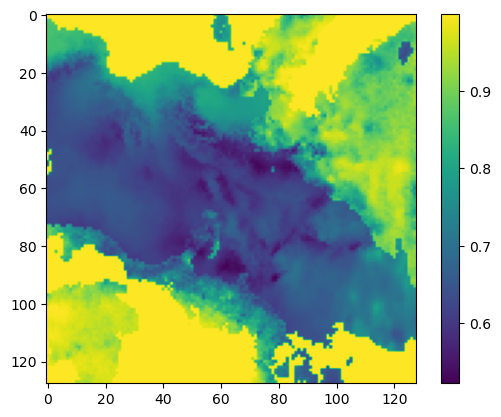

In [31]:
plt.imshow(hr_ds_norm["pr"][1000, :, :])
plt.colorbar()